In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


from flame_net.lib_uti import count_learnable_params
from flame_net.libKDV import CSolverKDV
from flame_net.libBurgers import CSolverBurgers
#from flame_net.uti_plot import *
import os

from flame_net.libKDV import libKDV
from flame_net.libBurgers import libBurgers
from flame_net.libData import libData


%matplotlib inline
import pickle

#np.random.seed(seed=1653)
from fractions import Fraction

#--------------------
device = torch.device('cuda')
bRNN=False
T_in=1
data_channel = 1 # model.data_channel

In [5]:

#dict_title = {'1dBurgers':r"1d-Burgers"}
dict_title = {'1dMS40':r"1d-MS($\beta=40$)", '1dMS25':r"1d-MS($\beta=25$)", '1dMS10':r"1d-MS($\beta=10$)",'1dKS40':r"1d-KS($\beta=40$)", '1dKS25':r"1d-KS($\beta=25$)", '1dKS10':r"1d-KS($\beta=10$)",'1dBurgers':r"1d-Burgers", '1dKDV':r"1d-KDV", '2dMS':r"2d-MS", '2dKS':r"2d-KS", '2dKDV':'2d-KDV'}

dict_err_RevtFNO_n= {'1dMS40':[2.78e-3, 0.00762],'1dMS25':[5.7e-4, 7.7e-4], '1dMS10':[1.88e-4,0.000194],'1dKS40':[2.48e-4, 0.000265],'1dKS25': [2.57e-4,2.68e-4 ], '1dKS10':[ 1.92E-4, 2.02E-4],'1dBurgers':[1.5E-4,1.9E-4], '1dKDV':[5.85e-4,5.27e-4 ], '2dMS':[4.36e-4,0.000322] , '2dKS':[3.34e-4,0.000351],'2dKDV':[4.3e-4, 4.3e-4] }
dict_err_RevtFNO_e= {'1dMS40':[0.0058, 0.0137 ] ,'1dMS25':[1.6e-3, 2.1e-3],'1dMS10':[8.38e-4,0.000861], '1dKS40':[1.9e-3, 0.0020], '1dKS25': [9.4e-4, 9.9e-4  ], '1dKS10':[ 9.22E-4, 9.91e-4]  ,'1dBurgers':[2.9E-4,4.0E-4],'1dKDV':[8.68e-4,9.22e-4] ,'2dMS':None,   '2dKS':None, '2dKDV':None } # '2dMS':[0.00128,0.00104], '2dKS':[1.97e-3,0.00211], '2dKDV':[2.8e-3, 2.9e-3]
dict_err_RevtFNO  = {'1dMS40':[0.0058, 0.0079],'1dMS25':[1.2e-3, 1.8e-3],'1dMS10':[8.42e-4,0.00088], '1dKS40':[0.00186, 0.002 ],'1dKS25': [1.1e-3, 1.2e-3  ], '1dKS10':[ 0.00114, 0.00118], '1dBurgers':[5.4E-4,6.7E-4], '1dKDV':[6.97e-4,0.000703] ,'2dMS': None , '2dKS':None, '2dKDV':None }
dict_err_kFNO_n   = {'1dMS40':[0.0037, 0.01 ] ,'1dMS25':[7.0e-4, 8.9e-4], '1dMS10':[4.12e-4,4.6e-4], '1dKS40':[4.03e-4, 0.000428 ],'1dKS25':[4.1e-4, 4.2e-4  ],'1dKS10':[0.000393,4.24e-4], '1dBurgers':[3.0E-4,4.1E-4],  '1dKDV':[7.26e-4,7.06e-4],'2dMS':None, '2dKS':None,'2dKDV':None  }
dict_err_kFNO_e   = {'1dMS40':[0.0083, 0.018] ,'1dMS25':[2.8e-3, 4.2e-3 ], '1dMS10':[1.02e-3,1.04e-3], '1dKS40':[2.15e-3, 0.00225 ],'1dKS25':[1.6e-3,1.7e-3   ],'1dKS10':[1.56e-3 ,1.62e-3],'1dBurgers':[7.4E-4,9.2E-4],  '1dKDV':[1.14e-3,0.00126]  ,'2dMS':None, '2dKS':None,'2dKDV':None  }
dict_err_kFNO     = {'1dMS40':[0.0045, 0.0063], '1dMS25':[3.2e-3,3.5e-3 ], '1dMS10':[0.0010,0.0011], '1dKS40':[0.00074, 0.00075],   '1dKS25':[2.0e-3,2.1e-3 ], '1dKS10':[0.00078, 0.00082],'1dBurgers':[4.4E-4,5.7E-4], '1dKDV':[9.97e-4, 0.00109] , '2dMS':[0.0015,0.0021], '2dKS':[0.0025,0.0025] , '2dKDV':[5.0e-4, 5.0e-4]}
dict_err_FNO      = {'1dMS40':[0.028, 0.028], '1dMS25':[0.02, 0.02],      '1dMS10':[0.0033,0.0034], '1dKS40':[0.0024, 0.0025],     '1dKS25':[0.011,0.012], '1dKS10':[0.0022, 0.0023]     ,'1dBurgers':[1.5E-3,1.8E-3], '1dKDV':[1.34e-3, 0.00144]  , '2dMS':[0.0041, 0.0030], '2dKS':[0.0053,0.0053], '2dKDV':[3.07e-3, 3.07e-3] }

dict_err_RevtFNO_e_kappa  = {'1dMS40':None,'1dMS25':None,'1dMS10':None, '1dKS40':None,'1dKS25':None, '1dKS10':None,'1dBurgers':None, '1dKDV':[1.17e-3,0.0012],  '2dMS': None,  '2dKS':None, '2dKDV':None}
dict_err_RevtFNO_e_kappa3 = {'1dMS40':None,'1dMS25':None,'1dMS10':None, '1dKS40':None, '1dKS25':None, '1dKS10':None,'1dBurgers':None, '1dKDV':[1.34e-3,0.00160], '2dMS': None, '2dKS': None, '2dKDV':None}
#----------------------

#list_key = ['1dKS10','1dKS40','1dMS10','1dMS40', '1dBurgers', '1dKDV','2dKS', '2dMS', '2dKDV']
list_key = [ '1dBurgers' ]

err_RevtFNO_n = [ dict_err_RevtFNO_n[key] for key in list_key ]
err_RevtFNO_e = [ dict_err_RevtFNO_e[key] for key in list_key ]
err_RevtFNO   = [ dict_err_RevtFNO[key]   for key in list_key ]
err_kFNO_n = [ dict_err_kFNO_n[key] for key in list_key ]
err_kFNO_e = [ dict_err_kFNO_e[key] for key in list_key ]
err_kFNO = [ dict_err_kFNO[key] for key in list_key ]
err_FNO = [ dict_err_FNO[key] for key in list_key ]
err_RevtFNO_e_kappa  = [ dict_err_RevtFNO_e_kappa[key] for key in list_key ]
err_RevtFNO_e_kappa3 = [ dict_err_RevtFNO_e_kappa3[key] for key in list_key ]


          
NNN = len(list_key)

str_title =  [ dict_title[key] for key in list_key ]

#----------------
model_err_data = [ err_RevtFNO_n, err_RevtFNO, err_RevtFNO_e, err_RevtFNO_e_kappa, err_RevtFNO_e_kappa3,      err_kFNO_n, err_kFNO,  err_kFNO_e, err_FNO ]
model_label    = ["IS-FNO$^o$", "IS-FNO$^*$", "IS-FNO'", "IS-FNO'$_\kappa$", "IS-FNO'$_{\kappa3}$",    "kFNO$^o$", "kFNO$^*$", "kFNO'", "FNO" ]
model_color    = ['red'       , 'purple',    'yellow',   'orange',           'violet',                   'g',      'b',         'c',    'lightgrey']
#--------------

#list_cases = [ 7,7,7,7,9,4,4,4]

list_cases = [ 0 for key in list_key ] 
for i, key in enumerate(list_key) :
  for err_model_j in model_err_data: 
      if err_model_j[i] is not None:
            list_cases[i]  += 1


/local/tmp.6263456/ipykernel_1776554/3531571118.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Train/Valid'], fontsize =13)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


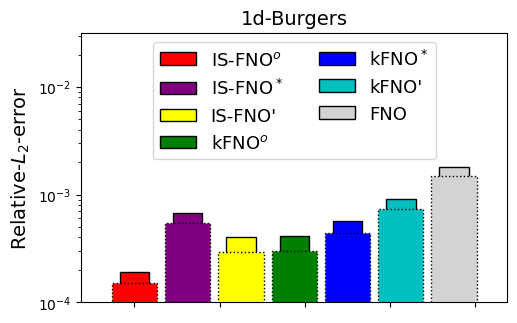

In [6]:

gs_kw = dict(width_ratios=list_cases )
#fig,ax = plt.subplots(1,NNN, figsize=(12,4.5),sharey=True, gridspec_kw=gs_kw )
fig,ax = plt.subplots(1,NNN, figsize=(5.5,3.5) ) # ,sharey=True, gridspec_kw=gs_kw )

#br = np.arange(2)
#=================
for j in range(NNN):
    
    #r_j = 0.5 if j==0 else 1
    r_j = 1

    w = 1/(list_cases[j]+1)
    ww = w*0.85
    
    #j0 = 2*(j-1)
    j0=j
    #ax = axs #[j] 

    s = 0
    for k , (model_err, color, label) in enumerate(zip(model_err_data, model_color, model_label ) ):
      if  model_err[j] is not None:
          ax.bar( s*w, model_err[j][1]*r_j, color =color, width = ww*.65, edgecolor ='k', label = label) ; 
          ax.bar( s*w, model_err[j][0]*r_j, color =color, width = ww, edgecolor ='k', linestyle=':' ) ; # label = label
          s = s+1
    
    ax.set_ylim([1E-4, 3.2E-2])
    ax.set_xlim([-w, 1-w])    #ax.set_xticks(br+0.5-w)    #ax.set_xticks(br+0.5-w)
    ax.set_xticklabels(['Train/Valid'], fontsize =13)
#=================

#lines, labels = axs[ np.argmax(list_cases)  ].get_legend_handles_labels()

#lines, labels = ax.get_legend_handles_labels()
#fig.legend(lines, labels, ncol=5, fontsize=14,  loc = 'upper center' )
plt.legend( ncol=2, fontsize=13,  loc = 'upper center' )



#fig.tight_layout()
#plt.subplots_adjust(left=0.06,bottom=0.1, right=1, top=.73, wspace=0.0) #left=0.08



#str_title = [r"DL, $\beta=40$",r"DL, $\beta=40$", r"DL, $\beta=10$",r"DT, $\beta=40$",r"DT, $\beta=10$"]

for j in range(NNN):
    #ax = axs[j]
    ax.set_yscale("log") 
    ax.set_title(str_title[j], fontsize =14)
    #ax.set_ylim([1e-4,4e-2])

    if j==0:
        ax.set_ylabel(r"Relative-$L_2$-error",fontsize=14)

    
#if png_filename is not None:
png_filename = 'ErrorTable_Burgers.eps' 
plt.savefig(png_filename, format='eps')

In [19]:
#change_to_new_model('tFNO_n')

In [20]:
models=[

  
  {'alias':'RevtFNO_n' ,'act_para':[1], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run1_RevtFNO_m128w30LpiBurgers1_tAdvD1_exp_nonl_o20_ep900',    'nStep':1,'Tout':20,'proj_dir':'' },
  {'alias':'RevtFNO_e' ,'act_para':[1], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run1_RevtFNO_m128w30LpiBurgers1_tAdvD1_exp_o20_ep900',         'nStep':1,'Tout':20,'proj_dir':'' },
  {'alias':'RevtFNO'   ,'act_para':[1], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m128w30LpiBurgers1_o20',                   'nStep':1,'Tout':20,'proj_dir':'' },

  {'alias':'tFNO_n'    ,'act_para':[1], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run2_tFNO_m128w30LpiBurgers1_tAdvD1_exp_nonl_o20_ep900','nStep':1,'Tout':20,'proj_dir':'' },
  {'alias':'tFNO_e'    ,'act_para':[1], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run1_tFNO_m128w30LpiBurgers1_tAdvD1_exp_o20',     'nStep':1,'Tout':20,'proj_dir':'' },
  {'alias':'tFNO'      ,'act_para':[1], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run2_tFNO_m128w30LpiBurgers1_o20',                'nStep':1,'Tout':20,'proj_dir':'' },
  {'alias':'tFNO_k1'   ,'act_para':[1], 'para_name':'Lpi','para_list':[], 'model_name_detail':'tFNO_m128w30LpiBurgers1_o20_k1',            'nStep':1,'Tout':20,'proj_dir':'' },
]

In [21]:

def change_to_new_model(model_alias, new_model_name_detail=None, proj_dir=None, models=models):
    for k, model in enumerate(models):
        if model['alias'] == model_alias: 
            print('model_index=', k, ', to be changed model name is:' , model['model_name_detail'] )
            if new_model_name_detail is None: 
                for i, s in enumerate( model):
                    print (i, s)
                return
            break

    if new_model_name_detail is not None:   
        model['model_name_detail']= new_model_name_detail
        print('change to ', new_model_name_detail)

    if proj_dir is not None:
        model['proj_dir']= proj_dir
        print('change to ', proj_dir)
        
    model['para_list'] = []

    key_pop_list = []    
    for j,  key in enumerate(model):
        if j >= 8:
            key_pop_list.append( key)

    for key in key_pop_list:
        print(key, ' deleted')
        model.pop(key, None)
                        
                
    return

In [22]:
def load_pkl( m ):
    str_filename = m['model_name_detail'] 
    if str_filename.find('_ep') >=0:         str_filename  = str_filename[ : str_filename.find('_ep') ]
    if str_filename.find('_best')>=0:        str_filename  = str_filename[ : str_filename.find('_best') ]
    open_file=open( m['proj_dir']+'./checkpoints/'+str_filename+ 'trainlog.pkl','rb')
    output_dict= pickle.load(open_file)
    open_file.close()
    train_residual = np.array ( [ os for os  in output_dict['list_output_info'] ] )
    return train_residual 
    
def plot_training_resid( m, list_iy=[2,3], ys='log',ix=0):
    train_residual = load_pkl( m)
    line_style = ['r-', 'g-.','b--','k.']
    for idx, y in enumerate(list_iy):
        plt.plot( train_residual[:,ix], train_residual[:,y], line_style[idx])
        #plt.plot( train_residual[:,ix], train_residual[:,y],'b-')
    plt.yscale(ys)
    
    return [ train_residual[:, y ][-1] for  y in list_iy ]

def print_train_info( list_iy=[2,3,1], models=models ):
    for idx, m in enumerate( models):
        train_residual = load_pkl( m)
        #----------------
        if 'ONet' in m['model_name_detail']:            method='ONet'
        elif  'Fourier' in m['model_name_detail']:      method='Fourier'
        elif  'Conv' in m['model_name_detail']:         method='Conv'
        else: method='FNO'
        #----------------
        print(idx, method, m['model_name_detail'], m['nStep'] ,m['Tout'],  [ train_residual[:, y ][-1] for  y in list_iy ] ) 

In [23]:
num_total_step=2000

In [24]:

list__init_str = 20*['rand_FFT'] # + 12*['rand_soli']
list__init_str_LongTerm= []       #  np.arange(40)
list_randseed = np.arange( len(list__init_str) ) + 563 #+18
Burgers = [  {'para_name':'Lpi', 'para_list':[], 'BurgersEq':CSolverBurgers('Burgers_RK4', [1]), 'N':256 ,'list_randseed':list_randseed },]


CSolverBurgers: nDIM= 1  N= 256  Lpi= 1  dt_Output= 0.00625 NumOutPut_dt= 20


In [25]:
def get_para_key( para_name, each_para_value):  # note: 'each_para_value' is allowed to be a list of values
    if 'Lpi'== para_name:   return 'Lpi{:d}_'.format(each_para_value[0])
    else:                   return '{}{:.3f}_'.format(para_name, each_para_value)
    

def get_sys(para_dict,Burgers=Burgers):
    for sys in Burgers:
        if para_dict['para_name'] == sys['para_name'] :    return sys
    raise ValueError('did not find sys')

def get_d0(i_which,sys,each_para_value,list__init_str=list__init_str):
    np.random.seed(seed= sys['list_randseed'][i_which])
    return libBurgers.rand_u0( sys['N'], each_para_value[0], list__init_str[i_which] )


def get_d0_all_from_para(sys, each_para_value): # nu
    d0_all=[]
    for i_which in range( len(sys['list_randseed']) ): 
        d0 = get_d0(i_which, sys, each_para_value)
        d0_all.append(d0)
    return np.array( d0_all )

def update_sys(sys, para_dict):
    if para_dict['para_name'] != sys['para_name']: assert(False)
    #-----------
    for each_para_value in para_dict['para_list']:
        if each_para_value not in sys['para_list']:
            sys['para_list'].append(each_para_value)
            sys = sys__add_a_single_para(sys, para_dict['para_name'], each_para_value)
    return sys

def sys__add_a_single_para(sys, para_name, each_para_value):
    
    d0_all   = get_d0_all_from_para( sys, each_para_value ) # ['nu'] )
    
    TotalTimeStep=num_total_step+1
    list_d_an=[]
    # --- init starting from either rand_FFT or rand ---
    for d0 in d0_all:
        d_an = sys['BurgersEq'].generate_dsol_single(TotalTimeStep, each_para_value[0], d0)  # d_an.shape ==numTotalTimeStep,  N
        print('d_an.shape=', d_an.shape)
        list_d_an.append(d_an) 
    
    
    each_para_key = get_para_key(para_name, each_para_value)
    
    sys[each_para_key+'list_d_an'] = np.array( list_d_an)
    sys['x'] = np.linspace(-1,1,sys['N'],endpoint=False)*np.pi 
    
    # sys[each_para_key+'list_NormalizedTotalLen_an'] = libData.dsol_to_whole_length(sys['x'], sys[each_para_key+'list_d_an'])
    
    return sys

In [26]:
def clean_models(model_alias, para_name , model_name_detail = None, models= models ):
    for m in models:
        if m['alias'] == model_alias and m['para_name']==para_name:
            m['para_list'] = []
            m.pop('model', None )
            if model_name_detail is not None: 
                m['model_name_detail'] = model_name_detail
            return models
    print( 'Did not find model_alias={} para_name={} to clean'.format(model_alias, para_name)   )
    return models

In [27]:
#models[0]['model'].conv_timeAdv.basis_type='mexp'

In [28]:
def load_model( model_name_detail, proj_dir):
    LocalFull_filename_Saved_Model = proj_dir+ './checkpoints/' + model_name_detail
    model = torch.load( LocalFull_filename_Saved_Model, map_location='cuda')
    print(model_name_detail, ' loaded in: count_learnable_params =' + str( count_learnable_params(model) ))
    return model


#             alias_name
def get_model(name, para_name,each_para_value,nStep,Tout, models, bLoadModel=True):
    
    for m in models:
        if para_name.casefold() != 'dd':     list_keywords = [ para_name.casefold() ] #, 'npara' ]
        else:                                list_keywords = [ ]

        if m['alias']==name and all( [keyword in m['model_name_detail'].casefold() for keyword in list_keywords ] ) and \
            m['nStep']==nStep and m['Tout']==Tout:

            if 'model' not in m  and bLoadModel==True:
                m['model'] = load_model( m['model_name_detail'] , m['proj_dir'] )

            if each_para_value not in m['para_list']:
                
                assert( each_para_value == m['act_para'] )
                
                m = update_model_pred( m, {'para_name':para_name,'para_list':[each_para_value] } )
                
            return m
        
    print( m['model_name_detail'])                
    raise ValueError('did not find model')

def update_model_pred(m, para_dict):
    m = get_model_pred(m, para_dict)
    return m

def get_model_pred(m, para_dict):
    para_name = para_dict['para_name']
    para_list = para_dict['para_list']
    
    nStep = m['nStep']

    #----- Burgers system ------
    sys = get_sys(para_dict, Burgers=Burgers)
    sys = update_sys(sys, para_dict)
    
    m['sys'] = sys
    m['x'] = sys['x']    
    #----
    NotYetReady__para_list = []
    for each_para_value in para_list:
        if each_para_value not in m['para_list']:
            NotYetReady__para_list.append(each_para_value)
    
    #-----
    for each_para_value in NotYetReady__para_list:
        m['para_list'].append(each_para_value)
        
        #---
        each_para_key = get_para_key(para_name, each_para_value)
        d0=sys[each_para_key+'list_d_an'][:,0,:] 
        d0_torch = torch.tensor(d0,dtype=torch.float).unsqueeze(-1)

        model = m['model']
        model.eval()
        with torch.no_grad():
            xx = d0_torch
            xx = xx.to(device)
            #print('get_model_pred: xx.shape', xx.shape)
            #print('get_model_pred: nu', nu)
            batch_size = xx.shape[0]
            
            #pdepara = torch.tile( torch.tensor(each_para_value,dtype=torch.float), (batch_size,1) ).to(device) 
            
            if '_k1' in m['model_name_detail']:      #  print('debug_test_else', xx) 

                for t in range(num_total_step//nStep):
                    im = model(xx )    # ,pdepara  )  
                    #--------------------
                    if t == 0:     pred = torch.cat((  xx, im), -1)
                    else:          pred = torch.cat((pred, im), -1)
                    #xx = torch.cat((xx[..., 1 * data_channel:], im), dim=-1)
                    xx = im
                    
            else:                         # if '_O' in m['model_name_detail']:
                
                T_out = 20
                model.kTimeStepping =  T_out
                
                for t in range(num_total_step//nStep//T_out):
                    #im = model(xx , 1  )  
                    im = model(xx , torch.arange(T_out).to(device)  )  
                    im = im.view( *im.shape[:-2], im.shape[-1] )
                    #--------------------
                    #print(t, 'im.shape=', im.shape, 'xx.shape=',xx.shape)
                    if t == 0:     pred = torch.cat((  xx, im[...,:T_out]), -1)
                    else:          pred = torch.cat((pred, im[...,:T_out]), -1)
                    #xx = im[...,-1:]

                    xx = im[...,T_out-1:T_out]
            
    
        list_pred = pred.detach().cpu().numpy()                   # list_pred.shape == (4, 512, 2000)
        
        m[each_para_key+'list_pred'] = np.moveaxis(list_pred,1,-1)

        #m['list_pred'] = np.moveaxis(list_pred,1,-1)
        print(each_para_key+'list_pred.shape=', m[each_para_key+'list_pred'].shape)

        #----
        # nu = m['nu']
        # sys = get_sys(nu)    
        #----
        m[each_para_key+'list_NormalizedTotalLen_pred'] = libData.dsol_to_whole_length(m['x'], m[each_para_key+'list_pred']  )

    return m

In [29]:
#list_i_t_plot = [0,            50, 125,250,500,750,1000,1250,1500,1750,2000]
#list_i_t_plot = [0,            50*2, 125*2,250*2,500*2,750*2,1000*2,1250*2,1500*2,1750*2,2000*2]
list_i_t_plot = [0,            50, 125,250,500,750,1000,1250,1500,1750,2000] 

In [30]:
# def alias_to_lengend_txt( model_alias ):
#     if model_alias == 'RevtFNO': return "rev-$kFNO$"
#     if model_alias == 'RevtFNO_e': return "rev-$kFNO^*$"  
#     if model_alias == 'RevtFNO_n':  return "rev-$kFNO'$"   
#     if model_alias == 'RevtFNO_k3': return "rev-$kFNO^*_{\kappa3}$"  
#     if model_alias == 'RevtFNO_k':  return "rev-$kFNO^*_{\kappa}$"   
#     if model_alias == 'RevtFNO_roll': return "rev-$kFNO^*_{roll}$"   
#     if model_alias == 'Rev222tFNO_e':  return "rev_3-$kFNO^*$"   
    
#     if model_alias == 'tFNO':  return "$kFNO$"           
#     if model_alias == 'tFNO_e': return "$kFNO^*$"       
#     if model_alias == 'tFNO_n': return "$kFNO'$"       
#     if model_alias == 'tFNO_k1': return"$FNO$"        
    
#     return model_alias          


def alias_to_lengend_txt( model_alias ):

    #n = model_alias.find('FNO') + 3  # '3' means '401', '100', etc...
    #model_alias = model_alias[:n] + model_alias[n+3:]
    
    if model_alias == 'RevtFNO': return "IS-FNO$^*$"
    if model_alias == 'RevtFNO_e': return "IS-FNO'"  
    if model_alias == 'RevtFNO_n':  return "IS-FNO$^o$"   
    if model_alias == 'RevtFNO_k3': return "IS-FNO'$_{\kappa3}$"  
    if model_alias == 'RevtFNO_k':  return "IS-FNO'$_{\kappa}$"   
    if model_alias == 'RevtFNO_roll': return "IS-FNO'$_{roll}$"   
    if model_alias == 'Rev222tFNO_e':  return "IS_3-FNO'"   
    
    if model_alias == 'tFNO':    return "kFNO$^*$"           
    if model_alias == 'tFNO_e':  return "kFNO'"       
    if model_alias == 'tFNO_n':  return "kFNO$^o$"       
    if model_alias == 'tFNO_k1': return "FNO"        
    
    return model_alias    

In [57]:
def plot_disp_long(all_list_model_alias, para_name, list_para, list_init, nCol_init, nStep, Tout,Tin, png_filename=None,
                   list_i_t_plot= list_i_t_plot ,  models= models ,SR_ratio = 1  ):

    
    list_lines_style=['-r','-.c', ':g','--b']

    R_ratio = 1; 

    m_init_row = len(list_init) // nCol_init

    
    figsize=(10/(2/nCol_init), 2.5*len(list_para)*m_init_row  )

    fig, axs = plt.subplots(   len(list_para)*m_init_row,  nCol_init, sharex=True, sharey=True, figsize= figsize , squeeze=False )
    #-----------------------------
    #axs=axs.reshape(len(list_para), nCol_init)
    #-----------------------------
    
    list_save__plt_handle = [ [ None for _ in list_model_alias] for list_model_alias in all_list_model_alias ]

    for idx, each_para_value in enumerate( list_para):
        
        m = get_model( all_list_model_alias[idx][0] , para_name, each_para_value, nStep, Tout,  models= models)
        x = m['x']
        each_para_key = get_para_key(para_name, each_para_value)
        
      
                
        for ax, i_init in zip(  axs[idx:(idx+m_init_row),:].reshape(-1),   list_init) :
            
            for idx_model, model_alias in enumerate(  all_list_model_alias[idx] ):
                m = get_model( model_alias, para_name, each_para_value, nStep, Tout ,  models= models)
                
                d_an  =  m['sys'][each_para_key+'list_d_an'][i_init]
                pred  =  m[each_para_key+'list_pred'][i_init]

                for i in list_i_t_plot:
                    d = (i)/20 #/2

                    if idx_model == 0:
                        h_ref,  = ax.plot( SR_ratio * d_an[i] + d,   x, color='black', linestyle='--', linewidth= 1 )
                    
                    if i > 0: 
                        h_pred, = ax.plot( SR_ratio *  pred[i] + d,   x, list_lines_style[idx_model] , linewidth=0.8 )  #, linewidth=1.5 )
                        list_save__plt_handle[idx][idx_model] = h_pred
                    

            #---------------------
            ax.set_yticks( [-np.pi,  np.pi] ); 
            ax.set_yticklabels(['0',  '2'] ,  fontsize=10  ) #,rotation='vertical')
            ax.set_ylabel('x', fontsize=11, labelpad=0)
            ax.yaxis.set_label_coords(-0.015,.5)
                

            #ax.set_xlim ( [-4, 33*np.pi ] )
            ax.set_xlim ( [-4, 16.*np.pi ] )
            ax.set_xticks( [ 0,  10, 50])  # 100 ] );    
            ax.set_xticklabels(['0','10','50'], fontsize=10 )# '100' ] , fontsize=10 )
            
            
            
                
            str_x_texts = r'$\phi(x,t_j)+j/20$' if SR_ratio==1 else r'${:g}\cdot\phi(x,t_j)+j/20$'.format( SR_ratio)
            ax.set_xlabel(str_x_texts , fontsize=12 )

            ax.xaxis.set_label_coords(0.5,-0.05)
            

            
    for ax in axs.flat:
        ax.label_outer()
 
    list_model_alias = all_list_model_alias[0]

    
    list_text_legend = ['Ref']+ [      alias_to_lengend_txt(model_alias)     for model_alias in list_model_alias]

    empty_handle =[plt.plot([],marker="", ls="")[0]]
    
    fig.legend(  empty_handle + [h_ref] + list_save__plt_handle[0], 
                 ['1d-Burgers :']   +  list_text_legend,
                 bbox_to_anchor=(0.7+ 0.08*(len(list_model_alias)-1) , 1.01) ,  ncol=len(list_model_alias)+1 +1 , fontsize=12 ,  frameon=False)
    #-----------------------

    fig.tight_layout()
    #plt.subplots_adjust(left=0.045, top=0.97,  wspace=0.01, hspace=0.0, right=0.97)
    plt.subplots_adjust(left=0.03, top=0.96,  wspace=0.01, hspace=0.0, right=0.99,bottom=0.025)

    
    if png_filename is not None:
        print('savefig: ', png_filename)
        if 'eps' in png_filename:
            plt.savefig(png_filename, format='eps')
        else:
            plt.savefig(png_filename, dpi=300)


In [58]:
#np.arange(0,80*13,80)

savefig:  Burgers_isFNO.eps


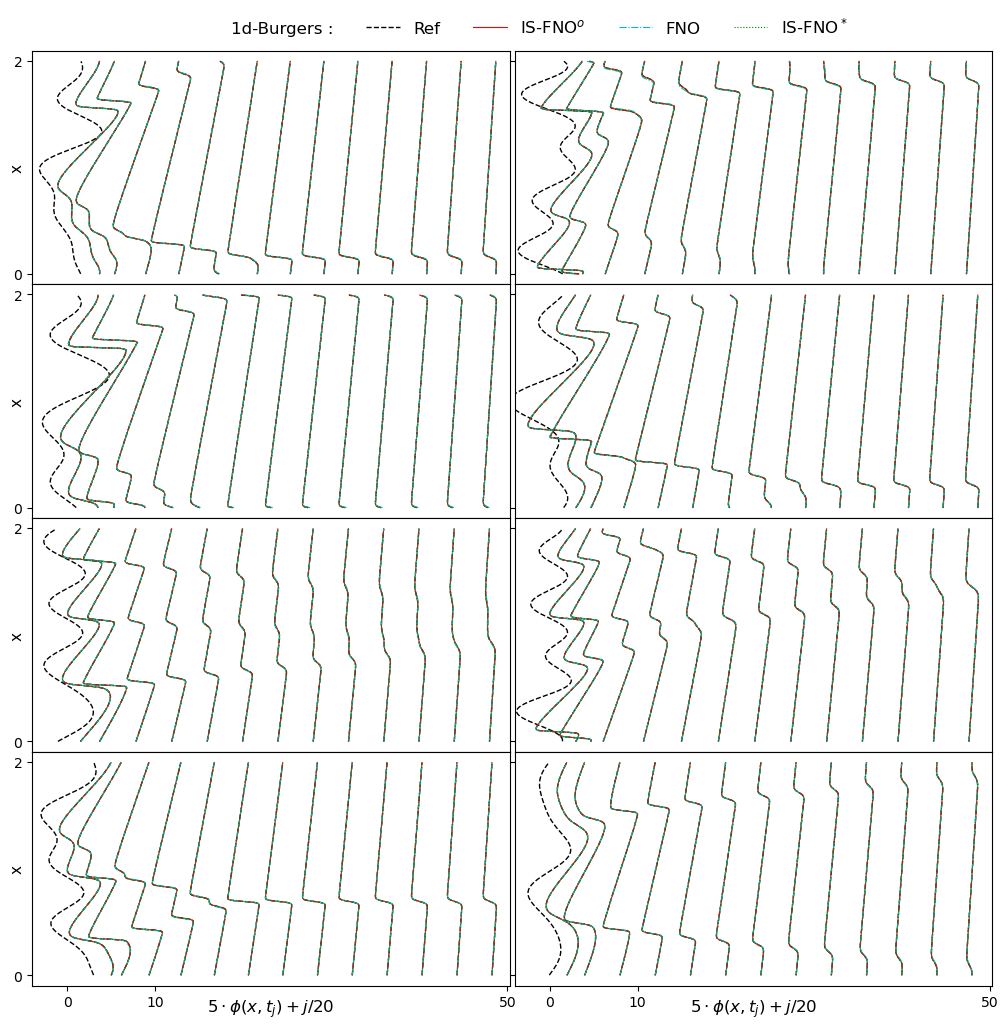

In [59]:
#list_i_t_plot = [0,    100 ,    200  , 300, 400, 500  ,600,   700 , 800 , 900, 1000]#,   1100,  1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000] 
list_i_t_plot = [0,   40 , 80,  160, 240, 320, 400, 480, 560, 640,720, 800,880, 960] 
#list_i_t_plot = np.arange(0,80*13,80)
para_name,  list_init, nCol_init, nStep, Tout,T_in, png_filename  =  'Lpi',  [7,2,3,5], 2, 1,  20,1, None 
All_list_para_values =[ [1]   ]

#list_init = [7,2,3,1,8, 14,15, 9]  #[4,0,3,6,1,9]
list_init = [0,1,2,3,7,9,14,15]
#list_init = [7,2,3,5,1,8,20, 25, 22, 27]  #[4,0,3,6,1,9]

All_list_model_names =[ ['RevtFNO_n','tFNO_k1','RevtFNO'] ]  #,'tFNO_k1'
png_filename = 'Burgers_isFNO.eps' # 'kdv_soliton_isFNO.eps'
plot_disp_long(All_list_model_names, para_name, All_list_para_values, list_init, 2, nStep, Tout, T_in, png_filename ,  models= models, list_i_t_plot=list_i_t_plot, SR_ratio = 5 )

In [34]:
# m = 7  #2 #  7  # 2, 7
# scatter_data = models[m]['model'].net_reversible( torch.tensor( models[m]['Lpi10_list_pred'][12,0:1000,:]).unsqueeze(-1).to(device) )
#for j in range(1,11):
#    plt.plot(  scatter_data[0,j,:].detach().cpu().numpy() )

In [35]:
#models[2]['sys']['Lpi10_list_d_an'].shape

In [36]:
# def forward(a):    return np.log(a)**2
# def inverse(a):    return np.exp( (a**0.5) )


In [51]:
def plot_compressed_errors(list_models_for_cmp ,line_legend,  png_filename=None, models= models) : 
    import matplotlib.gridspec as gridspec
    import numpy as np
    
    list__nStep_all       =[]
    list__m_all           = []
    list__each_para_key_all=[]
    list__pred_all          =[]
    for models_for_cmp in list_models_for_cmp:
        #-------
        nStep_all = [    m_['nStep'] for m_ in models_for_cmp] 
        m_all     = [ get_model(**m_ , models= models) for m_ in models_for_cmp]
        each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
        pred_all = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ] 
        #------
        list__pred_all.append(pred_all )
        list__each_para_key_all.append(each_para_key_all)
    #-----------
    
    str__para_name = [ r'$\rho$={}'.format(  Fraction( m['each_para_value'][0])  )   for m in models_for_cmp ]
    
    #---------------        
    x = m_all[0]['x']
    N = m_all[0]['sys']['N']
 
    #-----------
    N_end = num_total_step+1 #1500

    #------
    nCase = len(models_for_cmp)
    num_models = len(list_models_for_cmp) 
     
    list_text_legend =[ alias_to_lengend_txt(models_for_cmp[0]['name'])   for models_for_cmp in list_models_for_cmp ]

    fig, ax = plt.subplots( 1,  1 , figsize= [8, 1*5 ]) #, squeeze=False)
    #----------

    for icase in range(nCase):
        for idx, pred_all   in enumerate( list__pred_all  ):
            label = list_text_legend[idx]
            each_para_key_all = list__each_para_key_all[idx]
            
            d_an     = m_all[icase]['sys'][each_para_key_all[icase]+'list_d_an'][ ...,:N_end]
            #-----------    
            pred_pickplot =  pred_all[icase][ ...,:N_end]


            y = np.sqrt( (pred_pickplot - d_an)**2/(d_an**2).mean( axis=(-2,-1),keepdims=True ) ) 
            
            yy_1 = y[:20 ,:,:].mean( axis=(-3,-1), keepdims=False ) 
            
            #yy_2 = y[20: ,:,:].mean( axis=(-3,-1), keepdims=False ) 

            
            

            #-----
            ax.yaxis.set_ticks_position('both')


            ax.plot( np.arange(N_end),  yy_1  , line_legend[idx]  , label =  label  )   
        #------------------
        
        ax.set_xlim([1,1000])
        ax.set_xticks( [ 1, 100 ,  500 , 1000] )
        ax.set_xticklabels(['1','100','500', '1000'], fontsize=13 )
        ax.set_xlabel('$t/\Delta_t$',   fontsize=16)

        ax.set_title('1d-Burgers ', fontsize=15)
        ax.set_ylabel('Error', fontsize=15)
        #ax.label_outer()
    ax.set_ylim ( [2e-4, 0.4] )
    ax.set_yscale('log')
    #ax.set_xscale('log')
    
    #----------------
    #lines, labels = axs[ 0,0  ].get_legend_handles_labels()
    #fig.legend( ncol=4, fontsize=15 ,  loc = 'upper center' )

    #fig.tight_layout( )
    #fig.subplots_adjust(wspace=0.06, bottom=0.15 , top=0.75)  #wspace=0.05,hspace=0.05, 
    plt.legend( ncol=4, fontsize=14 ,  loc = 'upper center' )

    #---------------

        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300, transparent=True)    
                    


In [52]:
#change_to_new_model(model_alias, new_model_name_detail=None, proj_dir=None, models=models)



#change_to_new_model('tFNO_k1' ,'tFNO_m128w30LpiBurgers1_o20_k1' )


#change_to_new_model('tFNO_e','run1_tFNO_m128w30LpiBurgers1_tAdvD1_exp_o20')
#change_to_new_model('RevtFNO_e' , 'run1_RevtFNO_m128w30LpiBurgers1_tAdvD1_exp_o20_ep900')

#change_to_new_model('tFNO_n','run2_tFNO_m128w30LpiBurgers1_tAdvD1_exp_nonl_o20_ep900')#,'run2_tFNO_m128w30LpiBurgers1_tAdvD1_exp_nonl_o20_ep900')
#change_to_new_model('tFNO_n','run2_tFNO_m128w30LpiBurgers1_tAdvD1_exp_nonl_o20_ep900')#,'run2_tFNO_m128w30LpiBurgers1_tAdvD1_exp_nonl_o20_ep900')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


save png:  ave_err_1dBurgers.eps


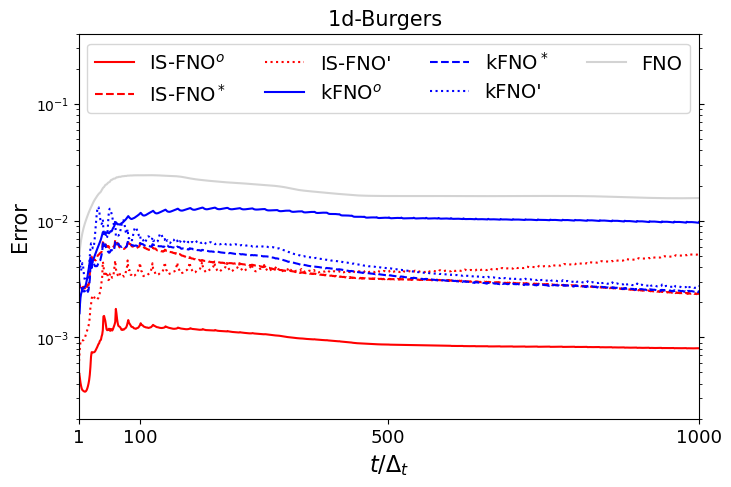

In [53]:


All_list_para_values =[  [1] ]
All_list_model_names =[ ['RevtFNO_n'   , 'RevtFNO',   'RevtFNO_e',
                         'tFNO_n',  'tFNO','tFNO_e', 
                         'tFNO_k1' ], ]


list_models_for_cmp =[ [{'name':All_list_model_names[idx][j], 'para_name':'Lpi','each_para_value': list_para_values ,'nStep':1,'Tout':20} 
                         for idx, list_para_values in enumerate(All_list_para_values) ] 
                         for j in  range(7) ]

line_legend = ['r-', 'r--','r:',              #'r-.' , 'c:' , # 'c:',
               'b-', 'b--', 'b:', 
               'lightgrey' ]

png_filename= None
png_filename= 'ave_err_1dBurgers.eps'
plot_compressed_errors(list_models_for_cmp,  line_legend,  png_filename=png_filename, models= models)

In [40]:
#models[7] =   {'alias':'trFNO_nonl'   ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run2_RevtFNO_m32w30LpiKDV10_tAdvD1_exp_nonl_o20',      'nStep':1,'Tout':20,'proj_dir':'' }
#models[-3] =  {'alias':'tFNO_nonlD2' ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'tFNO_m32w30LpiKDV10_o20',                'nStep':1,'Tout':20,'proj_dir':'' }

#models[-1] = {'alias':'tFNO_k1'     ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'lr1e4_KDV/tFNO_m32w30LpiKDV10_o20_k1',             'nStep':1,'Tout':20,'proj_dir':'' }

# models=[
#   {'alias':'trFNO_rw1_k'    ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30rw1LpiKDV10_tAdvD1_mexp_k_o20',  'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'trFNO_rw1_k3'   ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run2_RevtFNO_m32w30rw1LpiKDV10_tAdvD1_mexp_k^3_o20',  'nStep':1,'Tout':20,'proj_dir':'' },

#   {'alias':'trFNO_k3'       ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30LpiKDV10_tAdvD1_mexp_k^3_o20',  'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'trFNO_k'        ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30LpiKDV10_tAdvD1_mexp_k_o20',  'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'trFNO_roll'     ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run2_RevtFNO_m32w30LpiKDV10_tAdvD1_mexp_pure_roll_o20',  'nStep':1,'Tout':20,'proj_dir':'' },
  
#   {'alias':'trFNO'        ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30LpiKDV10_tAdvD1_mexp_o20',         'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'trFNO_rev222' ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30LpiKDV10D222_tAdvD1_mexp_o20_best',  'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'trFNO_nonl'   ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'run2_RevtFNO_m32w30LpiKDV10_tAdvD1_exp_nonl_o20',      'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'trFNO_D1'     ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30LpiKDV10_tAdvD1_o20',            'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'trFNO_D2'     ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30LpiKDV10_o20',                     'nStep':1,'Tout':20,'proj_dir':'' },

#   {'alias':'tFNO'        ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'tFNO_m32w30LpiKDV10_tAdvD1_mexp_o20',    'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'tFNO_nonlD2' ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'tFNO_m32w30LpiKDV10_o20',                'nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'tFNO_nonl'   ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'lr1e6_KDV/tFNO_m32w30LpiKDV10_tAdvD1_exp_nonl_o20','nStep':1,'Tout':20,'proj_dir':'' },
#   {'alias':'tFNO_k1'     ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'tFNO_m32w30LpiKDV10_o20_k1',             'nStep':1,'Tout':20,'proj_dir':'' },
# ]


#models[4] =  {'alias':'trFNO_roll'     ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'lr1e4_KDV/RevtFNO_m32w30LpiKDV10_tAdvD1_exp_pure_roll_o20',  'nStep':1,'Tout':20,'proj_dir':'' }
#models[3] =  {'alias':'trFNO_k'        ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'RevtFNO_m32w30LpiKDV10_tAdvD1_mexp_k_o20',  'nStep':1,'Tout':20,'proj_dir':'' }
#models[-2] =   {'alias':'tFNO_nonl'   ,'act_para':[10], 'para_name':'Lpi','para_list':[], 'model_name_detail':'lr1e6_KDV/tFNO_m32w30LpiKDV10_tAdvD1_exp_nonl_o20','nStep':1,'Tout':20,'proj_dir':'' }



In [41]:

def plot_para_slope(list_models_for_cmp , i_pickplot,  png_filename=None, models= models) :
    
    list__nStep_all       =[]
    list__m_all           = []
    list__each_para_key_all=[]
    list__pred_all          =[]

    for models_for_cmp in list_models_for_cmp:
        #-------
        nStep_all = [    m_['nStep'] for m_ in models_for_cmp] 
        m_all     = [ get_model(**m_ , models= models) for m_ in models_for_cmp]
        each_para_key_all = [ get_para_key( m_['para_name'], m_['each_para_value']) for m_ in models_for_cmp] 
        pred_all = [ m_[each_para_key+'list_pred'] for m_ , each_para_key in zip(m_all,each_para_key_all) ] 
        #------
        list__pred_all.append(pred_all )
        
    #-----------
    #str__para_name_legend = [ r'$\beta={:g},\rho={}$'.format(m['each_para_value'][0], Fraction( m['each_para_value'][1] ) )     for m in models_for_cmp ] 
        
    #---------------        
    x = m_all[0]['x']
    N = m_all[0]['sys']['N']
    
    
    #levels= np.linspace(-3.5,3.5,20)
    #levels= np.linspace(-15,15,20)
    
    levels=100
    
    cmap= 'rainbow'

    #-----------
    N_end = 2000 # num_total_step #1500
    
    def get_yy_xx(nStep,x=x, N_end = N_end):
        y = np.arange(num_total_step//nStep+1) * nStep
        xx,yy = np.meshgrid(x,y,indexing='xy')
        return yy[:N_end],xx[:N_end]

    def calc_slope( disp, N=N, N_end=N_end ):
        slope= np.diff(disp,axis=1,append=disp[:,0:1])/(2*np.pi/N)
        return slope[:N_end]

    #------
    nCase = len(models_for_cmp)

    num_models = len(list_models_for_cmp) 

    #fig, axs = plt.subplots(nCase, num_models+1 ,sharex=True, figsize= [12,nCase*1.5*1.25], squeeze=False)
    
    fig, axs = plt.subplots(nCase, num_models+1 ,sharex=True, figsize= [12,nCase*1.5*2], squeeze=False)
    
    cols = ['Ref'] + [   alias_to_lengend_txt(models_for_cmp[0]['name']) for models_for_cmp in list_models_for_cmp ]

    #----------
    #rows = [r"\rho={:g}".format(  model['each_para_value'][1]) for model in models_for_cmp ]

    for ax, col in zip(axs[0], cols):
        #ax.set_title('$'+col+'$', fontsize=14)
        ax.set_title(col, fontsize=14)

    #----------
    
    for icol, ax_cols in enumerate(  axs ) :
        
        #-----------
        d_an     = m_all[icol]['sys'][each_para_key_all[icol]+'list_d_an'][ i_pickplot ]
        #-----------    
        
        #ax_cols[0].contourf( *get_yy_xx(1)    , calc_slope(d_an)          , levels = levels ,cmap=cmap  )
        #ax_cols[0].contourf( *get_yy_xx(1)    ,             d_an          , levels = levels ,cmap=cmap  )
        ax_cols[0].contourf(                                 d_an.T          , levels = levels ,cmap=cmap  )

        for idx, pred_all in enumerate(list__pred_all):
            pred_pickplot =  pred_all[icol][ i_pickplot ]
            
            #ax_cols[idx+1].contourf( *get_yy_xx(1)    , calc_slope(pred_pickplot) , levels = levels ,cmap=cmap  )   
            #ax_cols[idx+1].contourf( *get_yy_xx(1)    ,             pred_pickplot , levels = levels ,cmap=cmap  )   
            ax_cols[idx+1].contourf(                    pred_pickplot.T , levels = levels ,cmap=cmap  )   
        #-----------    
                
        for idx, ax in enumerate(ax_cols):
            
            ax.set_yticks( [-np.pi, 0, np.pi] )
            if icol == 0:  
                ax.set_yticklabels(['-$\pi$', '0', '$\pi$'], fontsize=14,rotation='vertical')
            else:
                ax.set_yticklabels(['-$\pi$', '0', ''], fontsize=14,rotation='vertical')
            ax.set_ylabel('$x$',fontsize=12)
            
            ax.xaxis.set_tick_params(labelsize=14)
            ax.set_xlabel('$t/0.15$',fontsize=14)

            if idx == len(ax_cols)-1: 
                ax.yaxis.set_label_position("right")
            
    for ax in axs.flat:
        ax.label_outer()
        
    fig.tight_layout(  )
    plt.subplots_adjust(wspace=0.01,hspace=0.01)

        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)
        

In [42]:

list_para_values =[ [10] ]
#All_list_model_names =[ [ 'trFNO',  'trFNO_nonl' ]  ]

All_list_model_names =[ [ 'RevtFNO' ,'RevtFNO_n']   ]

list_models_for_cmp =[ [{'name':All_list_model_names[idx][j], 'para_name':'Lpi','each_para_value': para_value ,'nStep':1,'Tout':20} 
                         for idx, para_value in enumerate(list_para_values)    ]
                         for j in range(2) ]

png_filename= None #  'uSlope_1d_beta25.png'  #'uSlope_MKS_beta40.png'

plot_para_slope(list_models_for_cmp, i_pickplot=2, png_filename=png_filename , models= models)



AssertionError: 

In [ ]:

from scipy.optimize import fsolve
def _func_( b_c_eps_sigma, rho, beta, nu, mu ):
    b,c,eps,sigma = b_c_eps_sigma
    b2=b**2
    c2=c**2
    return [(b/c) - beta ,
             eps/c2 - nu,
            (1-sigma)*(b*c)-rho,
            4*(1+eps)**2/b2-mu*c2**2 ]

b_c_eps_sigma0_dict = { 0:[ 15, 0.38, 6.7, 1 ], 1:[ 9.27, 0.33 ,2 , 0.82 ] , 2:[7.3, 0.182 , 1.72 , 0.62 ], 3:[12.7, 0.3 , -4.4 , 0.81 ], 4: [40, 1, -1, 0.975 ] }    


def dispersion_relation(png_filename=None):
    kk = np.arange(128+1);
    
    #import matplotlib.gridspec as gridspec    
    
    fig = plt.figure( figsize=(16,4))

    #gs0 = gridspec.GridSpec(2, 7, figure=fig)
    #ax = fig.add_subplot(gs0[:,:3])

    ax = plt.subplot2grid((2, 7), (0, 0),  colspan=3, rowspan=3)
    ax1 = plt.subplot2grid((2, 7), (0, 5),  colspan=2, rowspan=1)
    ax12 = plt.subplot2grid((2, 7), (1, 5),  colspan=2, rowspan=1)    
    ax2 = plt.subplot2grid((2, 7), (0, 3),  colspan=2, rowspan=1)
    ax22 = plt.subplot2grid((2, 7), (1, 3),  colspan=2, rowspan=1)    
    
    colors=['r','g', 'orange', 'c' ,'k']
    for idx, Lpi in enumerate( [40] ):
        
        linestyle = '-' if idx==0 else '-.'
        
        for idc, d_ratio in enumerate( [0, 0.25,  0.5, .75 , 1 ] ):
            k = kk/Lpi;
            mu,nu, tau = libSiva.Coeff_Lpi_d_to_mu_nu_tau(Lpi, d_ratio, max_amplitude=0.25 )
            #print('Lpi:',Lpi, ' mu:', mu, 'nu:', nu, 'd_ratio:', d_ratio, 'tau:', tau)

            disp_relation = -(mu* k**4   - nu* k**2- d_ratio*k );
            if np.isclose(mu,0): mu =0
            if np.isclose(nu,0): nu =0
            if np.isclose(nu,1): nu =1
            if np.isclose(nu,-1): nu =-1
            

            my_label = r"$ \rho={} \:(\mu={:.2g}, \nu={:.2g})$".format(Fraction(d_ratio),mu, nu )
            #ax.plot( kk[np.where(kk<Lpi+1)], disp_relation[np.where(kk<Lpi+1) ], '-' , label= my_label )
            
            ax.plot( kk[np.where(kk<Lpi+10)]/Lpi, disp_relation[np.where(kk<Lpi+10) ], linestyle, color=colors[idc] , label= my_label )
    
    ax.set_ylabel(r'$ \omega(\kappa) /\tau  $', fontsize=15)
    ax.set_xlabel(r'$  \kappa /\beta  $', fontsize=15)
    ax.set_yticks([ 0,1/8, 1/4, ], ['0', '1/8','1/4']  )
    ax.set_xlim([0, 1.05])
    ax.set_ylim([-1/32,1/4+1/128])
    ax.tick_params(axis='x', labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    
    
    ax.yaxis.set_ticks_position('both')
    
    #ax.axhline(0,linestyle='-.', color='grey',linewidth=0.5)
    ax.legend(fontsize=12.5,  ncol=1 )
    
    #-----------------------------
    #-----------------------------
    #-----------------------------
    

    N=5

    list_Lpi =np.linspace(10,40,3)
    list_rho= np.linspace(0,1,N)
    list_b = np.zeros(N) 
    list_c = np.zeros(N) 
    list_eps = np.zeros(N) 
    list_sigma = np.zeros(N) 



    my_linestyle=[ 'k:<', 'k--s', 'k-*']
    for idx_Lpi, Lpi in enumerate(list_Lpi):
        for idx_rho,  rho in enumerate(list_rho):
            mu,nu, tau = libSiva.Coeff_Lpi_d_to_mu_nu_tau(Lpi, rho, max_amplitude=0.25 )

            func = lambda b_c_eps_sigma: _func_( b_c_eps_sigma, rho, Lpi, nu, mu )
            root = fsolve(func, b_c_eps_sigma0_dict[idx_rho] )
            b,c,eps,sigma = root
            #print(rho,Lpi, b,c,eps,sigma0 )
            list_b[idx_rho], list_c[idx_rho], list_eps[idx_rho], list_sigma[idx_rho]= b,c,eps,sigma

            if not any(np.isclose(func(root), [0, 0, 0, 0])) : print('error')

        strlabel = r'$\beta={:g}$'.format(Lpi)

        ax1.plot( list_rho, list_b,  my_linestyle[idx_Lpi], label=  strlabel)    
        ax12.plot( list_rho, list_c,     my_linestyle[idx_Lpi] , label= strlabel )    
        ax1.set_ylabel(r'$b$',fontsize=16)
        #ax1.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'])
        ax1.set_xticks([])
        ax1.tick_params(axis='y', labelsize=13)
        ax1.yaxis.set_ticks_position('both')
        
        ax12.set_ylabel(r'$c$',fontsize=16)
        ax12.set_xlabel(r'$\rho$',fontsize=16)
        ax12.tick_params(axis='y', labelsize=13)
        ax12.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'], fontsize=14)
        ax12.yaxis.set_ticks_position('both')

        ax2.plot( list_rho, list_eps, my_linestyle[idx_Lpi] , label=  strlabel)    
        ax2.set_ylabel(r'$Le^*$',fontsize=16)
        ax2.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'])
        ax2.tick_params(axis='y', labelsize=13)
        ax2.yaxis.set_ticks_position('both')
        ax2.set_xticks([])
        
        ax22.plot( list_rho, 1/list_sigma,  my_linestyle[idx_Lpi] , label= strlabel )    
        ax22.set_ylabel(r'$1/\Omega$',fontsize=16)
        ax22.set_xlabel(r'$\rho$',fontsize=16 )
        ax22.tick_params(axis='y', labelsize=13)
        ax22.set_xticks([ 0,1/4,1/2, 3/4,1 ], ['0', '1/4','1/2','3/4', '1'], fontsize=14)
        ax22.yaxis.set_ticks_position('both')


    
    ax1.legend( fontsize=12.5 , ncol=2)
    fig.tight_layout()
    
    #---------------------------------
    
    if png_filename is not None:
        #ax.set_rasterized(True)
        print('savefig: ', png_filename)
        if 'eps' in png_filename:
            plt.savefig(png_filename, format='eps' )
        else:
            plt.savefig(png_filename, dpi=300)    
#dispersion_relation('dRel_ana.eps')

In [ ]:
ra_cx = 0.01* torch.ones(1,256)
n = ra_cx.shape[-1]//2
zero_pad =  torch.zeros (  *ra_cx.shape[:-1], 1).to(ra_cx.device)
length   = ra_cx[...,:n+1]
angle    = torch.cat( [ zero_pad,  ra_cx[...,n+1:], zero_pad] , dim =-1)
cx  = length.unsqueeze(-1)*torch.stack([torch.cos( angle), torch.sin( angle)], dim=-1)

In [ ]:
#------------------
# def my_irfft( ra_cx ):  # rx.shape = 1, 256
#     n = ra_cx.shape[-1]//2
#     zero_pad =  torch.zeros (  *ra_cx.shape[:-1], 1).to(ra_cx.device)
#     length   = ra_cx[...,:n+1]
#     angle    = torch.cat( [ zero_pad,  ra_cx[...,n+1:], zero_pad] , dim =-1)
#     cx  = length.unsqueeze(-1)*torch.stack([torch.cos( angle), torch.sin( angle)], dim=-1)    
#     return torch.fft.irfft( torch.view_as_complex(cx) )
# def my_rfft(x):
#    cx = torch.fft.rfft( x ,dim=-1)
#    ra_cx = torch.cat( [cx.abs(), cx.angle()[...,1:-1] ], dim=-1)
#    return ra_cx

def my_irfft( rx ):  # rx.shape = 1, 256//2+1 
   return torch.fft.irfft( rx )
def my_rfft(x):
   cx = torch.fft.rfft( x, dim=-1)
   return cx.abs()                # shape 256//N+1

def my_model( ra_cx,  para_value  , model, x_steady = 0 ):
    
    x = my_irfft( ra_cx ).unsqueeze(-1)
    
    #x = x + x_steady.to(x.device)
    #pdepara = torch.tile( torch.tensor( para_value,dtype=torch.float), (1,1) ).to(device) 

    if para_value is None:
        y = model(  x )
    else:
        pdepara = torch.tensor([[ para_value ]], dtype=torch.float).to(device) 
        y = model(  x,  pdepara)
 
    
    #y = y.view( *y.shape[:-1] )   # remove the last dimention
    
    if y.ndim == x.ndim :
        y = y[...,-1]                  # remove the last dimention
    elif y.ndim > x.ndim :
        y = y[...,0,-1]
        
    ra_cy = my_rfft( y )
    
    return ra_cy


#
#all_list_model_names = [ ['pFNO*','pCNN10'] ,['pFNO*'] , ['pFNO*','pCNN40'] ]
#list_models = [model_search['model']  for model_search in models for model_alias in list_model_names if  model_search['alias'] == model_alias ]     
#
def calc_dispersion_relation_for_models(all_list_model_names, list_Lpi, List_rho  ): 

    MaxNum_model = len(all_list_model_names[0])
    dispersion_relation_models  = np.zeros( ( MaxNum_model, len(list_Lpi), len(list_rho), 256//2+1           ) )
    jacobian_all                = np.zeros( ( MaxNum_model, len(list_Lpi), len(list_rho), 256//2+1 ,256//2+1 ) )

    for idx_Lpi, list_model_names  in enumerate( all_list_model_names):
        
        Lpi = list_Lpi[idx_Lpi]   # For AI-fluid , this is fix to be Lpi==25
        
        #----
        x_perturb = 1E-2
        rx = x_perturb* torch.ones(1,256//2+1).to(device)

        for idx_rho, rho in enumerate(list_rho):
            for idx_model, model_names in enumerate(list_model_names):
                #------------------------------------------------
                model = None
                nOutStep_Koopman = 20
                for model_search in models:
                    if np.isclose( rho, model_search['act_para'][-1] ): 
                        if model_names == 'FNO' and '_k1' in model_search['alias']:
                            model = model_search['model'] 
                            nOutStep_Koopman = 1
                        elif model_names == 'kFNO'and '_k1' not in model_search['alias']:
                            model = model_search['model'] 
                            nOutStep_Koopman = 20
                #------------------------------------------------
            
                jacobian_now = torch.autograd.functional.jacobian(lambda t_: my_model(t_, None, model), rx)
                #jacobian_now = torch.autograd.functional.jacobian(lambda t_: my_model(t_, [Lpi,rho], model), rx)
                
                #print(jacobian_now.shape) 
                
                my_jac =  jacobian_now[0,:,0,:].detach().cpu()

                jacobian_all[idx_model,idx_Lpi,idx_rho,:,:] = my_jac

                dispersion_relation_models[idx_model,idx_Lpi,idx_rho, :] = np.log(np.diag( my_jac[:,:]  ) )/(0.15*nOutStep_Koopman)  # 0.15 is time step
                dispersion_relation_models[idx_model,idx_Lpi,idx_rho, 0] = 0

    return dispersion_relation_models, jacobian_all

def ananlytical_dispersion_relation(  list_Lpi, List_rho ):
    kk = np.arange(128+1);
    disp_rel = np.zeros( ( len(list_Lpi), len(list_rho) , 129)  )
    for idx_Lpi, Lpi in enumerate(list_Lpi):
        for idx_rho, d_ratio in enumerate(list_rho):
            k = kk/Lpi;
            mu,nu, tau = libSiva.Coeff_Lpi_d_to_mu_nu_tau(Lpi, d_ratio, max_amplitude=0.25 )
            disp_relation = -(mu* k**4   - nu* k**2- d_ratio*k );
            if np.isclose(mu,0): mu =0
            if np.isclose(nu,0): nu =0
            if np.isclose(nu,1): nu =1
            if np.isclose(nu,-1): nu =-1
            disp_rel[idx_Lpi,idx_rho, :] =  (tau)*disp_relation
    return disp_rel

In [ ]:
list_rho=[0, 0.25, 0.5, 0.75, 1]
#list_Lpi= [10, 25, 40]
list_Lpi= [25]
disp_rel_analytical = ananlytical_dispersion_relation(list_Lpi, list_rho)


In [ ]:
#all_list_model_names = [ ['pFNO*','pFNO','pCNN10'] ,['pFNO*', 'pFNO'] , ['pFNO*','pFNO', 'pCNN40'] ]

all_list_model_names = [ ['kFNO','FNO'] ]
#all_list_model_names = [ ['kFNO'] ]

#-----
disp_rel_models , jacobian_all  = calc_dispersion_relation_for_models( all_list_model_names, list_Lpi, list_rho )

In [ ]:
from fractions import Fraction

def cmp_plt_dispersion_relation( all_list_model_names,  disp_rel_models,  disp_rel_analytical, list_Lpi, list_rho,png_filename):

    kk = np.arange(128+1);

    
    rho_colors=['r','g', 'orange', 'c' ,'k']
    model_style=['-.',':','--']

    
    fig, ax = plt.subplots(1,len(list_Lpi), figsize=(5,3 ))
    #fig, axs = plt.subplots(1,len(list_Lpi)+1, figsize=(8,4 ))
    
    for idx_Lpi , Lpi in enumerate(list_Lpi):
        
        #ax = axs[idx_Lpi]

        k_cut = Lpi+6
        
        
        lines =[]
        for i, d_ratio in enumerate(list_rho) :
            
            my_label = r"{}".format(Fraction(d_ratio))
            
            lines += ax.plot( kk[:k_cut], disp_rel_analytical[idx_Lpi,i,:k_cut] , linestyle= '-', color= rho_colors[i], alpha=0.15, linewidth=3, label= my_label )
            

        for m in  range( len(all_list_model_names[idx_Lpi]) ):
            for i, d_ratio in enumerate(list_rho) :
                lines += ax.plot( kk[:k_cut], disp_rel_models[m,idx_Lpi,i,:k_cut] ,linestyle= model_style[m], color= rho_colors[i], linewidth= 1  ) # , label= my_label )



        if idx_Lpi==0:    ax.set_ylabel(r'$  \omega(\kappa)$', fontsize=13)
        
        ax.set_xlim([0, Lpi*1.1])

        if Lpi==40:      ax.set_ylim([-1/16,1])             #ax.set_yticks([-1/8, 0,1/8, 1/4], ['-1/4', '0', '1/2', '1'])
        elif Lpi==25:    ax.set_ylim([-1/16,1])
        else:            ax.set_ylim([-1/16,1])            #ax.set_yticks([ 0, 1/16], [ '0', '1/16' ])

        ax.plot([0,0], [k_cut,0])
        ax.set_xlabel('$\kappa$', fontsize=14)
        #ax.set_yticks([ 0, 1/4, 1/2, 3/4, 1], ['0', '1/4','1/2', '3/4','1'], fontsize=14)

        #ax.set_yticks([-1/4, 0, 1/4, 1/2,3/4], ['-1/4','0', '1/4','1/2','3/4'], fontsize=13)
        #ax.set_yticks([  0, 1/2, ], ['0','1/2' ], fontsize=13)

        ax.set_ylim([-1.5/4, 3/4]) 
        
        #ax.tick_params(axis='x', labelsize=14)
        
        #str_legend_title = r"$\beta={:g},\rho$".format( Lpi)
        str_legend_title = r"$(\rho)$"
        le= ax.legend( title=str_legend_title,loc="lower center"  ,  fontsize=13, frameon=True, borderpad=0,labelspacing=0.1 , ncol=3)
        le.get_title().set_fontsize('14')
        
        from matplotlib.legend import Legend
        leg = Legend(ax, lines[4::5], ['Ref']+all_list_model_names[idx_Lpi] , fontsize=14,   loc='upper right', frameon=True, borderpad=0,labelspacing=0.1 )
        ax.add_artist(leg);        
        #ax.set_title( r'$\beta={:g}$'.format(Lpi) , fontsize=13 ) 
        #--------------------------------------

        
     
    # for ax in axs.flat:
    #     #ax.set_rasterized(True)
    #     ax.label_outer()
    # #----------------
    # ax=axs[-1]
    # # [idx_model,idx_Lpi,idx_rho,  :  ,  :]
    # #(       3  ,   3   ,   5   , 129 , 129)    
    # ax.imshow( jacobian_all[0, -1, -1,:45,:45 ] ) 
    # ax.set_title( r'$J(\kappa, \overline{\kappa})$ at ${\beta=25,\rho=1}$, kFNO' , fontsize=16 ) 
    # ax.set_xlabel(r'$\kappa$', fontsize=16)
    # ax.set_ylabel(r'$\overline{\kappa}$', fontsize=16)
    # ax.tick_params(axis='x', labelsize=14)

 
    # #----------------
    # fig.tight_layout()
    # plt.subplots_adjust(left=0.045, right=1, top=0.91, wspace=0.05)
        
        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)

In [ ]:
cmp_plt_dispersion_relation(  all_list_model_names, disp_rel_models, disp_rel_analytical, list_Lpi, list_rho , png_filename='drel_1d_beta25.png')


In [ ]:

def plt_operator_jacobian( all_list_model_names,  disp_rel_models,  disp_rel_analytical, list_Lpi, list_rho,png_filename):

    kk = np.arange(128+1);
    rho_colors=['r','g', 'orange', 'c' ,'k']
    model_style=['--','-.',':']
    model_name=['pFNO*','pFNO','pCNN40']

    fig, axs = plt.subplots(2,2, figsize=(8,8))

    Lpi_s=[0, 2]
    m_s  =[0, 2]
    
    for i, i_Lpi in enumerate(Lpi_s):
        for j, j_m in enumerate(m_s):
            # [idx_model,idx_Lpi,idx_rho,  :  ,  :]
            #(       3  ,   3   ,   5   , 129 , 129)
            ax = axs[i,j]   
            ax.imshow( jacobian_all[i_Lpi, j_m, -1,:50,:50 ] ) 
            
            ax.set_xlabel(r'$\kappa$', fontsize=14)
            ax.set_ylabel(r'$\kappa^*$', fontsize=14)

            ax.set_title(r'$J(\kappa,\kappa^*)$ of {}'.format(model_name[j_m]), fontsize=14)
     
    for ax in axs.flat:
        ax.label_outer()
        
    fig.tight_layout()
    plt.subplots_adjust(left=0.045, right=0.99, top=0.99, wspace=0.05)
        
        
    if png_filename is not None:
        print('save png: ',png_filename )
        plt.savefig(png_filename,dpi=300)

#plt_operator_jacobian(  all_list_model_names, disp_rel_models, disp_rel_analytical, list_Lpi, list_rho , png_filename= None)
